In [1]:
'''
import urllib
import geopandas as gpd
import os
from pathlib import Path

#CHANGE THIS
url = "https://gis.alambukit30.com/geoserver/ows?service=WFS&version=1.0.0&request=GetFeature&typename=geonode%3ALC1990_2020v1&outputFormat=json&srs=EPSG%3A32748&srsName=EPSG%3A32748"

response = urllib.request.urlopen(url)
jsonfile = response.read()
home = str(Path.home())
foo = open(os.path.join(home,"tempgpd.json"),"wb")
foo.write(jsonfile)
'''

21371831

In [4]:
import sys
!{sys.executable} -m pip install xlrd

    100% |████████████████████████████████| 112kB 129kB/s ta 0:00:01


In [205]:
import pandas as pd

df = pd.read_excel('Carbon_Raw_data.xlsx')
display(df)

,OBJECTID,Shape,FID_PENUTUPAN_LAHAN_UNION,FID_PENUTUPAN_LAHAN_2018_AR,PL_18_ID,Carbon_ID,StocktC_Ha,Luas,Stock_tC,Hutan_non,...,Sumber,FID_BATAS_KECAMATAN_AR,DISTRIK,FID_PENUTUPAN_LAHAN_2017_AR,pl17_id,Luas (Ha),FID_PENUTUPAN_LAHAN_1996_AR,PL96_ID,Shape_Length,Shape_Area
0,1,Polygon ZM,4,3,2005,5,84,270518,22723512,Hutan,...,BBSDLP Kementrian Pertanian,18,SUMURI,4,2005,0.004014,-1,0,2173.777201,4.014438e+01
1,2,Polygon ZM,5,8,3000,13,5,17547,87735,Non-Hutan,...,BBSDLP Kementrian Pertanian,18,SUMURI,9,3000,0.000872,-1,0,566.084388,8.717686e+00
2,3,Polygon ZM,6,3,2005,5,84,270518,22723512,Hutan,...,BBSDLP Kementrian Pertanian,18,SUMURI,4,2005,0.001306,-1,0,1198.263539,1.306151e+01
3,4,Polygon ZM,29,11,20051,6,68,38175,2595900,Hutan,...,BBSDLP Kementrian Pertanian,18,SUMURI,12,20051,0.000021,-1,0,21.618120,2.050450e-01
4,5,Polygon ZM,60,1,2002,4,85,614870,52263950,Hutan,...,NaN,1,AROBA,2,2002,0.000028,-1,0,55.182484,2.804920e-01
5,6,Polygon ZM,68,1,2002,4,85,614870,52263950,Hutan,...,BBSDLP Kementrian Pertanian,1,AROBA,2,2002,0.000004,-1,0,8.863910,3.629100e-02
6,7,Polygon ZM,149,10,20041,2,120,86988,10438560,Hutan,...,NaN,1,AROBA,11,20041,0.000513,-1,0,176.270635,5.125933e+00
7,8,Polygon ZM,552,-1,0,0,0,0,0,NaN,...,NaN,18,SUMURI,-1,0,432.885168,-1,0,91873.643749,4.328852e+06
8,9,Polygon ZM,574,10,20041,2,120,86988,10438560,Hutan,...,NaN,18,SUMURI,11,20041,0.000017,-1,0,13.088285,1.684530e-01
9,10,Polygon ZM,622,-1,0,0,0,0,0,NaN,...,NaN,7,KAMUNDAN,-1,0,43.722547,-1,0,13377.734176,4.372255e+05


In [287]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10659 entries, 0 to 10658
Data columns (total 50 columns):
OBJECTID                       10659 non-null int64
Shape                          10659 non-null object
FID_PENUTUPAN_LAHAN_UNION      10659 non-null int64
FID_PENUTUPAN_LAHAN_2018_AR    10659 non-null int64
PL_18_ID                       10659 non-null int64
Carbon_ID                      10659 non-null int64
StocktC_Ha                     10659 non-null int64
Luas                           10659 non-null int64
Stock_tC                       10659 non-null int64
Hutan_non                      9365 non-null object
Label                          9365 non-null object
FID_PENUTUPAN_LAHAN_2016_AR    10659 non-null int64
pl16_id                        10659 non-null int64
FID_PENUTUPAN_LAHAN_2015_AR    10659 non-null int64
PL15_ID                        10659 non-null int64
FID_PENUTUPAN_LAHAN_2014_AR    10659 non-null int64
PL14_ID                        10659 non-null int64
FID_PE

In [207]:
plID = pd.read_csv('pl-id.csv')
plID

,No,Kode,Toponimi,Keterangan
0,1,2001,Hp,Hutan Lahan Kering Primer
1,2,2002,Hs,Hutan Lahan Kering Sekunder
2,3,2004,Hmp,Hutan Mangrove Primer
3,4,2005,Hrp,Hutan Rawa Primer
4,5,20041,Hms,Hutan Mangrove Sekunder
5,6,20051,Hrs,Hutan Rawa Sekunder
6,7,2006,Ht,Hutan Tanaman
7,8,2007,B,Belukar
8,9,2010,Pk,Perkebunan
9,10,2012,Pm,Pemukiman


In [321]:
plidict=plID['Kode'].to_dict()
print(plidict)
plilist= []
for k in plidict.keys():
    temp = plidict[k]
    plilist.append(temp)
print(plilist)

{0: 2001, 1: 2002, 2: 2004, 3: 2005, 4: 20041, 5: 20051, 6: 2006, 7: 2007, 8: 2010, 9: 2012, 10: 2014, 11: 2500, 12: 3000, 13: 5001, 14: 20071, 15: 20091, 16: 20092, 17: 20093, 18: 20094, 19: 20121, 20: 20122, 21: 20141, 22: 50011}
[2001, 2002, 2004, 2005, 20041, 20051, 2006, 2007, 2010, 2012, 2014, 2500, 3000, 5001, 20071, 20091, 20092, 20093, 20094, 20121, 20122, 20141, 50011]


In [322]:
meltdf = pd.melt(df, id_vars=['DISTRIK','Luas (Ha)'], value_vars= ['PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID',
                                                                'PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID','pl16_id',
                                                                'pl17_id','PL_18_ID'])

indx = [0] +plilist
meltdf[['value']] = pd.Categorical(meltdf['value'],indx)
meltdf = meltdf.sort_values(['value','DISTRIK'],ascending=[True,True]).reset_index(drop=True)
meltdf

,DISTRIK,Luas (Ha),variable,value
0,ARANDAY,0.091995,PL90_ID,0
1,ARANDAY,3.826654,PL90_ID,0
2,ARANDAY,17.934486,PL90_ID,0
3,ARANDAY,1.015642,PL90_ID,0
4,ARANDAY,0.308995,PL90_ID,0
5,ARANDAY,0.012804,PL90_ID,0
6,ARANDAY,0.075627,PL90_ID,0
7,ARANDAY,0.091995,PL96_ID,0
8,ARANDAY,3.826654,PL96_ID,0
9,ARANDAY,17.934486,PL96_ID,0


In [323]:
#indx = ['Forest','YRF','Scrub','Rubber','Palm Oil', 'Open Land','Water Body']
Repiv = meltdf.pivot_table(values='Luas (Ha)',index=['variable'],columns=['DISTRIK','value'],aggfunc='sum', margins=True)
Repiv = Repiv.reset_index()
Repiv = Repiv.iloc[:-1]
indx = ['PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID']
Repiv[['variable']] = pd.Categorical(Repiv['variable'],indx)
Repiv = Repiv.rename(columns={"All":"Total Area"})
Repiv = Repiv.sort_values(['variable'],ascending=[True]).reset_index(drop=True)
Repiv

DISTRIK  variable    ARANDAY                                         \
value                      0         2001         2002         2004   
0         PL90_ID  23.266203  2544.960089  3063.340491  2994.004318   
1         PL96_ID  23.266203  2544.960089  3063.340491  2994.004318   
2         PL00_ID  23.266203   346.467345  5261.833235  2994.004318   
3         PL03_ID  23.266203   346.467345  5261.833235  2994.004318   
4         PL06_ID  23.266203   346.467345  5261.833235  2994.004318   
5         PL09_ID  23.266203   346.467345  5261.833235  2994.004318   
6         PL11_ID  23.266203   346.467345  5261.833235  2994.004318   
7         PL12_ID  23.266203   346.467345  5261.833235  2994.004318   
8         PL13_ID  23.266203   346.467345  5261.833235  2994.004318   
9         PL14_ID  23.266203   346.467345  5261.833235  2994.004318   
10        PL15_ID  23.266248   346.467345  5261.833302  2994.004318   
11        pl16_id  37.216319   346.467345  5261.833235  2992.851270   
12        pl17_id  23.266203   346.467345  5259.313743  2994.004318   
13       PL_18_ID  55.167668   346.467345  5259.313700  2993.707628   

DISTRIK                                                               ...  \
value            2005      20041        20051        2007       2012  ...   
0        36552.524831  205.78342  4119.890811  119.732006        NaN  ...   
1        36552.524831  205.78342  4119.890811  119.732006        NaN  ...   
2        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
3        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
4        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
5        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
6        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
7        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
8        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
9        36189.128789        NaN  3845.116438  682.424386        NaN  ...   
10       36189.128722        NaN  3845.116393  656.398232  26.026154  ...   
11       36189.128789        NaN  3844.724846  655.934151  26.026154  ...   
12       36189.128789        NaN  3845.116438  656.398232  28.545646  ...   
13       36189.128712        NaN  3836.567359  648.125091  35.696786  ...   

DISTRIK     WARIAGAR                                                   \
value           2005       20041        20051         2007       2012   
0        2255.289426  832.480092  3230.241785  1442.291226        NaN   
1        2255.289426  832.480092  3230.241785  1442.291226        NaN   
2        2255.289426  832.480092  3230.241785  1442.291226        NaN   
3        2255.289426  832.480092  3230.241785  1442.291226        NaN   
4        2255.289426  832.480092  3230.241785  1442.291226        NaN   
5        2255.289426  832.480092  3230.241785  1442.291226        NaN   
6        2255.289426  832.480092  3230.241785  1442.291226        NaN   
7        2255.289426  832.480092  3230.241785  1442.291226        NaN   
8        2255.289426  832.480092  3230.241785  1442.291226        NaN   
9        2255.289426  832.480092  3230.241785  1442.291124        NaN   
10       2255.289426  869.254028  3230.241785  1442.291124  11.918189   
11       2255.289426  826.432365  3227.762536  1442.291153  11.918243   
12       2255.289426  869.254028  3230.241785  1442.291193  11.918243   
13       2255.289426  825.526358  3212.164525  1442.291102  66.428836   

DISTRIK                                                   Total Area  
value         2014        3000       5001        20071                
0        11.918243  684.937984  67.614932  2064.370568  1.925856e+06  
1        11.918243  684.937984  67.614932  2064.370568  1.925856e+06  
2        11.918243  684.937984  67.614932  2064.370568  1.925856e+06  
3        11.918243  684.937984  67.614932  2064.370568  1.925856e+06  
4        11.918243  684.937984  67.

In [324]:
dTranspose = Repiv.T
dTranspose

0            1            2            3   \
DISTRIK    value                                                       
variable              PL90_ID      PL96_ID      PL00_ID      PL03_ID   
ARANDAY    0          23.2662      23.2662      23.2662      23.2662   
           2001       2544.96      2544.96      346.467      346.467   
           2002       3063.34      3063.34      5261.83      5261.83   
           2004          2994         2994         2994         2994   
           2005       36552.5      36552.5      36189.1      36189.1   
           20041      205.783      205.783          NaN          NaN   
           20051      4119.89      4119.89      3845.12      3845.12   
           2007       119.732      119.732      682.424      682.424   
           2012           NaN          NaN          NaN          NaN   
           2014       14.3693      14.3693      14.3693      14.3693   
           3000       978.549      978.549      998.631      998.631   
           5001       739.341      739.341      739.341      739.341   
           20071      1670.45      1670.45      1931.63      1931.63   
AROBA      0          550.411       550.48      550.411      550.411   
           2001       64157.8      64156.5          NaN          NaN   
           2002       54154.8      54154.8       116780       116780   
           2004       10642.8      10643.1        10632      9777.41   
           2005       569.465      569.491      569.465      569.465   
           20041      21319.6      21318.9      21145.5        22000   
           2007       918.142      918.488      2570.42      2570.42   
           2012       106.821      106.872      106.821      106.821   
           2014       3.08814      3.08814      68.1866      68.1866   
           2500       51.3206      51.3226      51.3206      51.3206   
           3000        2604.8      2605.47       2604.8       2604.8   
           5001       8015.81      8016.24      8015.81      8015.81   
           20071      10.8864      10.8874      10.8864      10.8864   
BABO       0          1823.21      1823.24      1823.21      1823.21   
           2001       2915.01      2915.04          NaN          NaN   
           2002       45.9665      45.9665      2960.98      2960.98   
...                       ...          ...          ...          ...   
TUHIBA     2005       1811.13      1811.13      1811.13      1811.13   
           2007           NaN          NaN      70.6069      70.6069   
           2010       107.227      107.227      902.697      902.697   
           5001       273.883      273.765      273.883      273.883   
           20092          NaN          NaN          NaN          NaN   
WAMESA     0          1065.58      1065.73      1065.58      1065.58   
           2001       59598.1        59598      57045.6      57045.6   
           2002       934.685      934.764      3487.13      3487.13   
           2004       62556.2      62555.3      62556.2      62556.2   
           2005       5159.89      5159.97      5159.89      5159.89   
           20041      7497.98      7498.01      7497.98      7497.98   
           2007       519.082      519.096      519.082      519.082   
           2012       22.4061      22.4062      22.4061      22.4061   
           2014       62.1388      62.1402      62.1388      62.1388   
           2500       2.73121      2.73121      2.73121      2.73121   
           3000       24.4293      24.4417      24.4293      24.4293   
           5001       11623.6      11624.3      11623.6      11623.6   
WARIAGAR   0          23.3772      23.3772      23.3772      23.3772   
           2001       25.8584      25.8584      25.8584      25.8584   
           2004       99.1696      99.1696      99.1696      99.1696   
           2005       2255.29      2255.29      2255.29      2255.29   
           20041       832.48       832.48       832.48       832.48   
           20051      3230.24      3230.24      3230.24      3230.2

In [349]:
df_calc = df[['DISTRIK','Tipe','PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID','Luas (Ha)']]
df_calc = df_calc.sort_values('DISTRIK')
df_calc = df_calc[df_calc['DISTRIK'].notna()]
df_calc

,DISTRIK,Tipe,PL90_ID,PL96_ID,PL00_ID,PL03_ID,PL06_ID,PL09_ID,PL11_ID,PL12_ID,PL13_ID,PL14_ID,PL15_ID,pl16_id,pl17_id,PL_18_ID,Luas (Ha)
1688,ARANDAY,nonGambut,2005,2005,2007,2007,2007,2007,2007,2007,2007,2007,2007,0,2007,0,0.006855
1758,ARANDAY,Gambut,5001,5001,5001,5001,5001,5001,5001,5001,5001,5001,5001,5001,5001,5001,35.285933
1757,ARANDAY,Gambut,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,136.404379
1756,ARANDAY,Gambut,2005,2005,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,20.081256
1755,ARANDAY,Gambut,2014,2014,2014,2014,2014,2014,2014,2014,2014,2014,2014,2014,2014,2014,10.462138
1754,ARANDAY,Gambut,20051,20051,20051,20051,20051,20051,20051,20051,20051,20051,20051,20051,20051,2012,2.791300
1753,ARANDAY,Gambut,20051,20051,2007,2007,2007,2007,2007,2007,2007,2007,2012,2012,2012,2012,12.726099
1752,ARANDAY,Gambut,20051,20051,2007,2007,2007,2007,2007,2007,2007,2007,2012,2012,2012,2012,13.211506
1751,ARANDAY,Gambut,20051,20051,2007,2007,2007,2007,2007,2007,2007,2007,2007,2007,2007,2007,143.833734
1750,ARANDAY,Gambut,20041,20041,2007,2007,2007,2007,2007,2007,2007,2007,2007,2007,2007,2007,176.969882


In [422]:
hutan = [2001,2002,2004,2005,20041,20051,2006]
nonhutan = [2007,2010,2012,2014,2500,3000,5001,20071,20091,20092,20093,20094,20121,20122,20141,50011]
def deforested(df,x0,x1):
    df[x1+"_Deforested"] = (df[x0].isin(hutan)) & (df[x1].isin(nonhutan))

X0 = ['PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id']
X1 = ['PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID']

for i in range(len(X0)):
#    print(X1[i])
#    df_calc[X1[i]+"_Deforested"] = deforested(df_calc,X0[i],X1[i])
    deforested(df_calc,X0[i],X1[i])
df_calc['Tipe'] = df_calc['Tipe'].fillna(value="nonGambut")    
df_calc.to_csv("def.csv")

In [401]:
melt_def = pd.melt(df_calc, id_vars=['DISTRIK','Tipe','Luas (Ha)'], value_vars= [x+"_Deforested" for x in X1])
melt_def

,DISTRIK,Tipe,Luas (Ha),variable,value
0,ARANDAY,nonGambut,0.006855,PL96_ID_Deforested,False
1,ARANDAY,Gambut,35.285933,PL96_ID_Deforested,False
2,ARANDAY,Gambut,136.404379,PL96_ID_Deforested,False
3,ARANDAY,Gambut,20.081256,PL96_ID_Deforested,False
4,ARANDAY,Gambut,10.462138,PL96_ID_Deforested,False
5,ARANDAY,Gambut,2.791300,PL96_ID_Deforested,False
6,ARANDAY,Gambut,12.726099,PL96_ID_Deforested,False
7,ARANDAY,Gambut,13.211506,PL96_ID_Deforested,False
8,ARANDAY,Gambut,143.833734,PL96_ID_Deforested,False
9,ARANDAY,Gambut,176.969882,PL96_ID_Deforested,False


In [458]:
Repiv_def = melt_def.pivot_table(values='Luas (Ha)',index=['variable'],columns=['DISTRIK','Tipe','value'],aggfunc='sum', margins=True)
Repiv_def = Repiv_def.reset_index()

indx = [x+"_Deforested" for x in X1]# + ["All"]

Repiv_def[[('variable','','')]] = pd.Categorical(Repiv_def[('variable','','')],indx)
Repiv_def = Repiv_def.sort_values([('variable','','')],ascending=[True]).reset_index(drop=True)

#Repiv_def = Repiv_def.iloc[:,:-1]

Repiv_def = Repiv_def.rename(columns={"All":"Total Area"})
display(Repiv_def)
#Repiv_def.info()
#display(indx)


DISTRIK             variable        ARANDAY                            \
Tipe                                 Gambut                 nonGambut   
value                                 False        True         False   
0         PL96_ID_Deforested   48883.968689         NaN   4142.243195   
1         PL00_ID_Deforested   48213.980493  669.988196   3968.277556   
2         PL03_ID_Deforested   48883.968689         NaN   4142.243195   
3         PL06_ID_Deforested   48883.968689         NaN   4142.243195   
4         PL09_ID_Deforested   48883.968689         NaN   4142.243195   
5         PL11_ID_Deforested   48883.968689         NaN   4142.243195   
6         PL12_ID_Deforested   48883.968689         NaN   4142.243195   
7         PL13_ID_Deforested   48883.968689         NaN   4142.243195   
8         PL14_ID_Deforested   48883.968689         NaN   4142.243195   
9         PL15_ID_Deforested   48883.968689         NaN   4142.243195   
10        pl16_id_Deforested   48883.968689         NaN   4141.892803   
11        pl17_id_Deforested   48883.968689         NaN   4139.723703   
12       PL_18_ID_Deforested   48881.177361    2.791328   4139.628469   
13                       NaN  634818.813433  672.779524  53669.711286   

DISTRIK                      AROBA                                         \
Tipe                        Gambut                 nonGambut                
value          True          False        True         False         True   
0               NaN   37502.620240    0.464569  1.256001e+05     2.541604   
1        173.965639   37077.845812  425.238997  1.243090e+05  1293.647666   
2               NaN   37503.084809         NaN  1.256026e+05          NaN   
3               NaN   37503.084809         NaN  1.256026e+05          NaN   
4               NaN   37503.084809         NaN  1.256026e+05          NaN   
5               NaN   37503.084809         NaN  1.256026e+05          NaN   
6               NaN   37503.084809         NaN  1.256026e+05          NaN   
7               NaN   37409.546532   93.538277  1.256026e+05          NaN   
8               NaN   37503.084809         NaN  1.256026e+05          NaN   
9               NaN   37503.084809         NaN  1.256026e+05          NaN   
10         0.350392   37325.103296  177.981513  1.252934e+05   309.244619   
11         2.519492   37497.321101    5.763708  1.255890e+05    13.609197   
12         2.614726   37503.084091    0.000718  1.256026e+05     0.001851   
13       179.450249  486837.114735  702.987782  1.631215e+06  1619.044937   

DISTRIK           BABO  ...         TUHIBA                     WAMESA  \
Tipe            Gambut  ...      nonGambut                     Gambut   
value            False  ...          False        True          False   
0         17566.513833  ...   46634.413349    0.218428   26206.823631   
1         17566.686000  ...   45768.218329  866.413448   26206.970740   
2         17566.686000  ...   46634.631777         NaN   26207.069748   
3         17566.686000  ...   46634.631777         NaN   26207.069748   
4         17528.793340  ...   46634.631777         NaN   26207.069748   
5         17566.686000  ...   46634.631777         NaN   26207.069748   
6         17566.686000  ...   46634.631777         NaN   26207.069748   
7         17566.686000  ...   46634.631777         NaN   26207.069748   
8         17566.686000  ...   46634.631777         NaN   26198.379537   
9         17566.686000  ...   46634.631777         NaN   26207.069748   
10        17566.686000  ...   46630.788502    3.843275   26207.069748   
11        17566.686000  ...   46634.631777         NaN   26206.567826   
12        17566.686000  ...   46634.631307    0.000470   26207.069487   
13       228328.853173  ...  605379.737480  870.475621  340682.369205   

DISTRIK                                          WARIAGAR                \
Tipe                  nonGambut                    Gambut     nonGambut   
value        True         False       True          Fals

In [459]:
Total_def = Repiv_def.T
Total_def = Total_def.reset_index()
#display(Total_def)

colName = {}
keys = [x for x in range(len(X1))] + [13]
values = indx + ["Total Deforestasi"]
for key in keys: 
    for value in values: 
        colName[key] = value 
        values.remove(value) 
        break

Total_def = Total_def.rename(columns=colName)
#display(Total_def)
Total_def = Total_def[Total_def['value']==True]#.reset_index()
#new_header = Total_def.iloc[0] #grab the first row for the header
#Total_def = Total_def[1:] #take the data less the header row
#Total_def.columns = new_header
#display(new_header)
display(Total_def)
#display(Total_def.drop(['Tipe'], axis=1).groupby(by=["DISTRIK"]).sum())

,DISTRIK,Tipe,value,PL96_ID_Deforested,PL00_ID_Deforested,PL03_ID_Deforested,PL06_ID_Deforested,PL09_ID_Deforested,PL11_ID_Deforested,PL12_ID_Deforested,PL13_ID_Deforested,PL14_ID_Deforested,PL15_ID_Deforested,pl16_id_Deforested,pl17_id_Deforested,PL_18_ID_Deforested,Total Deforestasi
2,ARANDAY,Gambut,True,NaN,669.988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.79133,672.78
4,ARANDAY,nonGambut,True,NaN,173.966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.350392,2.51949,2.61473,179.45
6,AROBA,Gambut,True,0.464569,425.239,NaN,NaN,NaN,NaN,NaN,93.5383,NaN,NaN,177.982,5.76371,0.000718,702.988
8,AROBA,nonGambut,True,2.5416,1293.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,309.245,13.6092,0.001851,1619.04
10,BABO,Gambut,True,0.172167,NaN,NaN,NaN,37.8927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0648
12,BABO,nonGambut,True,0.382352,0.374213,NaN,NaN,14.388,NaN,NaN,NaN,NaN,NaN,NaN,5.71759,5e-06,20.8621
14,BINTUNI,Gambut,True,0.000147,468.283,NaN,NaN,NaN,NaN,156.59,88.0039,NaN,21.7128,128.274,28.043,7.8e-05,890.907
16,BINTUNI,nonGambut,True,0.06149,494.871,NaN,NaN,NaN,NaN,174.611,179.503,NaN,36.5779,45.7365,33.7377,NaN,965.099
18,BISCOOP,nonGambut,True,0.498816,71.7577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.34,0.000418,0.003103,244.6
20,DATARAN BIEMES,nonGambut,True,0.100886,56.2948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.7413,10.8167,0.001393,121.955


In [460]:
Total_def[Total_def['Tipe']=='Gambut']

,DISTRIK,Tipe,value,PL96_ID_Deforested,PL00_ID_Deforested,PL03_ID_Deforested,PL06_ID_Deforested,PL09_ID_Deforested,PL11_ID_Deforested,PL12_ID_Deforested,PL13_ID_Deforested,PL14_ID_Deforested,PL15_ID_Deforested,pl16_id_Deforested,pl17_id_Deforested,PL_18_ID_Deforested,Total Deforestasi
2,ARANDAY,Gambut,True,NaN,669.988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.79133,672.78
6,AROBA,Gambut,True,0.464569,425.239,NaN,NaN,NaN,NaN,NaN,93.5383,NaN,NaN,177.982,5.76371,0.000718,702.988
10,BABO,Gambut,True,0.172167,NaN,NaN,NaN,37.8927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.0648
14,BINTUNI,Gambut,True,0.000147,468.283,NaN,NaN,NaN,NaN,156.59,88.0039,NaN,21.7128,128.274,28.043,7.8e-05,890.907
24,KAMUNDAN,Gambut,True,1.04964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.3281,NaN,19.4034,36.7811
28,KANTARO,Gambut,True,0.55494,183.456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.61527,NaN,188.626
32,KURI,Gambut,True,0.314966,0.2138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.070965,1.64969,6.7e-05,2.24949
36,MANIMERI,Gambut,True,1.70121,837.903,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.93278,NaN,0.00013,841.537
55,SUMURI,Gambut,True,1.78031,1060.58,NaN,91.6672,NaN,NaN,NaN,0.181229,NaN,62.6526,546.965,40.8512,0.941964,1805.62
62,TOMU,Gambut,True,0.865048,244.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.677,NaN,NaN,262.062


In [461]:
Total_def[Total_def['Tipe']=='nonGambut']

,DISTRIK,Tipe,value,PL96_ID_Deforested,PL00_ID_Deforested,PL03_ID_Deforested,PL06_ID_Deforested,PL09_ID_Deforested,PL11_ID_Deforested,PL12_ID_Deforested,PL13_ID_Deforested,PL14_ID_Deforested,PL15_ID_Deforested,pl16_id_Deforested,pl17_id_Deforested,PL_18_ID_Deforested,Total Deforestasi
4,ARANDAY,nonGambut,True,NaN,173.966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.350392,2.51949,2.61473,179.45
8,AROBA,nonGambut,True,2.5416,1293.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,309.245,13.6092,0.001851,1619.04
12,BABO,nonGambut,True,0.382352,0.374213,NaN,NaN,14.388,NaN,NaN,NaN,NaN,NaN,NaN,5.71759,5e-06,20.8621
16,BINTUNI,nonGambut,True,0.06149,494.871,NaN,NaN,NaN,NaN,174.611,179.503,NaN,36.5779,45.7365,33.7377,NaN,965.099
18,BISCOOP,nonGambut,True,0.498816,71.7577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172.34,0.000418,0.003103,244.6
20,DATARAN BIEMES,nonGambut,True,0.100886,56.2948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.7413,10.8167,0.001393,121.955
22,FAFRUWAR,nonGambut,True,0.116526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,694.254,NaN,0.000518,694.371
26,KAMUNDAN,nonGambut,True,0.090237,0.994212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.835,5.04464,33.7104,71.6744
30,KANTARO,nonGambut,True,0.29894,107.365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000267,NaN,4.7e-05,107.664
34,KURI,nonGambut,True,0.252887,NaN,NaN,NaN,NaN,NaN,NaN,27.4623,348.323,NaN,4.26899,84.4007,38.7415,503.45


In [462]:
dg_calc = df[['DISTRIK','Tipe','PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID','Luas (Ha)']]
dg_calc = dg_calc.sort_values('DISTRIK')
dg_calc = dg_calc[dg_calc['DISTRIK'].notna()]
dg_calc

hutan = [2001,2004,2005]
deghutan = [2002,20041,20051,2006]
def degraded(df,x0,x1):
    df[x1+"_Degraded"] = (df[x0].isin(hutan)) & (df[x1].isin(deghutan))

X0 = ['PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id']
X1 = ['PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID']

for i in range(len(X0)):
#    print(X1[i])
#    df_calc[X1[i]+"_Deforested"] = deforested(df_calc,X0[i],X1[i])
    degraded(dg_calc,X0[i],X1[i])
dg_calc['Tipe'] = dg_calc['Tipe'].fillna(value="nonGambut")    
dg_calc

,DISTRIK,Tipe,PL90_ID,PL96_ID,PL00_ID,PL03_ID,PL06_ID,PL09_ID,PL11_ID,PL12_ID,...,PL06_ID_Degraded,PL09_ID_Degraded,PL11_ID_Degraded,PL12_ID_Degraded,PL13_ID_Degraded,PL14_ID_Degraded,PL15_ID_Degraded,pl16_id_Degraded,pl17_id_Degraded,PL_18_ID_Degraded
1688,ARANDAY,nonGambut,2005,2005,2007,2007,2007,2007,2007,2007,...,False,False,False,False,False,False,False,False,False,False
1758,ARANDAY,Gambut,5001,5001,5001,5001,5001,5001,5001,5001,...,False,False,False,False,False,False,False,False,False,False
1757,ARANDAY,Gambut,3000,3000,3000,3000,3000,3000,3000,3000,...,False,False,False,False,False,False,False,False,False,False
1756,ARANDAY,Gambut,2005,2005,3000,3000,3000,3000,3000,3000,...,False,False,False,False,False,False,False,False,False,False
1755,ARANDAY,Gambut,2014,2014,2014,2014,2014,2014,2014,2014,...,False,False,False,False,False,False,False,False,False,False
1754,ARANDAY,Gambut,20051,20051,20051,20051,20051,20051,20051,20051,...,False,False,False,False,False,False,False,False,False,False
1753,ARANDAY,Gambut,20051,20051,2007,2007,2007,2007,2007,2007,...,False,False,False,False,False,False,False,False,False,False
1752,ARANDAY,Gambut,20051,20051,2007,2007,2007,2007,2007,2007,...,False,False,False,False,False,False,False,False,False,False
1751,ARANDAY,Gambut,20051,20051,2007,2007,2007,2007,2007,2007,...,False,False,False,False,False,False,False,False,False,False
1750,ARANDAY,Gambut,20041,20041,2007,2007,2007,2007,2007,2007,...,False,False,False,False,False,False,False,False,False,False


In [463]:
melt_deg = pd.melt(dg_calc, id_vars=['DISTRIK','Tipe','Luas (Ha)'], value_vars= [x+"_Degraded" for x in X1])
melt_deg

,DISTRIK,Tipe,Luas (Ha),variable,value
0,ARANDAY,nonGambut,0.006855,PL96_ID_Degraded,False
1,ARANDAY,Gambut,35.285933,PL96_ID_Degraded,False
2,ARANDAY,Gambut,136.404379,PL96_ID_Degraded,False
3,ARANDAY,Gambut,20.081256,PL96_ID_Degraded,False
4,ARANDAY,Gambut,10.462138,PL96_ID_Degraded,False
5,ARANDAY,Gambut,2.791300,PL96_ID_Degraded,False
6,ARANDAY,Gambut,12.726099,PL96_ID_Degraded,False
7,ARANDAY,Gambut,13.211506,PL96_ID_Degraded,False
8,ARANDAY,Gambut,143.833734,PL96_ID_Degraded,False
9,ARANDAY,Gambut,176.969882,PL96_ID_Degraded,False


In [465]:
Repiv_deg = melt_deg.pivot_table(values='Luas (Ha)',index=['variable'],columns=['DISTRIK','Tipe','value'],aggfunc='sum', margins=True)
Repiv_deg = Repiv_deg.reset_index()
indx = [x+"_Degraded" for x in X1] # + ["All"]

Repiv_deg[[('variable','','')]] = pd.Categorical(Repiv_deg[('variable','','')],indx)
Repiv_deg = Repiv_deg.sort_values([('variable','','')],ascending=[True]).reset_index(drop=True)

#Repiv_def = Repiv_def.iloc[:,:-1]

Repiv_deg = Repiv_deg.rename(columns={"All":"Total Area"})
display(Repiv_deg)


DISTRIK           variable        ARANDAY                             \
Tipe                               Gambut                  nonGambut   
value                               False         True         False   
0         PL96_ID_Degraded   48883.968689          NaN   4142.243195   
1         PL00_ID_Degraded   47453.966277  1430.002412   3373.752863   
2         PL03_ID_Degraded   48883.968689          NaN   4142.243195   
3         PL06_ID_Degraded   48883.968689          NaN   4142.243195   
4         PL09_ID_Degraded   48883.968689          NaN   4142.243195   
5         PL11_ID_Degraded   48883.968689          NaN   4142.243195   
6         PL12_ID_Degraded   48883.968689          NaN   4142.243195   
7         PL13_ID_Degraded   48883.968689          NaN   4142.243195   
8         PL14_ID_Degraded   48883.968689          NaN   4142.243195   
9         PL15_ID_Degraded   48883.968689          NaN   4142.243128   
10        pl16_id_Degraded   48883.968689          NaN   4142.243195   
11        pl17_id_Degraded   48883.968689          NaN   4142.243195   
12       PL_18_ID_Degraded   48883.968689          NaN   4142.243195   
13                     NaN  634061.590545  1430.002412  53080.671136   

DISTRIK                      AROBA                                            \
Tipe                        Gambut                   nonGambut                 
value          True          False          True         False          True   
0               NaN   37502.997253      0.087556  1.256007e+05      1.941795   
1        768.490332   30315.418003   7187.666806  6.899657e+04  56606.032711   
2               NaN   36709.632807    793.452002  1.255415e+05     61.092944   
3               NaN   37503.084809           NaN  1.256026e+05           NaN   
4               NaN   35222.145034   2280.939775  1.245498e+05   1052.809357   
5               NaN   37503.084809           NaN  1.256026e+05           NaN   
6               NaN   37503.084809           NaN  1.256026e+05           NaN   
7               NaN   37503.084809           NaN  1.256026e+05           NaN   
8               NaN   37503.084809           NaN  1.256026e+05           NaN   
9          0.000067   37503.084809           NaN  1.256026e+05      0.001189   
10              NaN   37503.084809           NaN  1.256026e+05           NaN   
11              NaN   37503.084809           NaN  1.256026e+05           NaN   
12              NaN   37503.084809           NaN  1.256026e+05      0.000192   
13       768.490399  477277.956378  10262.146139  1.575112e+06  57721.878188   

DISTRIK           BABO  ...         TUHIBA                      WAMESA  \
Tipe            Gambut  ...      nonGambut                      Gambut   
value            False  ...          False         True          False   
0         17566.686000  ...   46634.631777          NaN   26207.009023   
1         15587.213821  ...   46100.490701   534.141076   24641.251778   
2         17566.686000  ...   46634.631777          NaN   26207.069748   
3         17566.686000  ...   46634.631777          NaN   26207.069748   
4         17566.686000  ...   46634.631777          NaN   26207.069748   
5         17566.686000  ...   46634.631777          NaN   26207.069748   
6         17566.686000  ...   46634.631777          NaN   26207.069748   
7         17566.686000  ...   46634.631777          NaN   26207.069748   
8         17566.686000  ...   46634.631777          NaN   26207.069748   
9         17566.686000  ...   46634.629128     0.002649   26207.063530   
10        17566.686000  ...   46595.504740    39.127037   26207.069748   
11        17566.686000  ...   46046.504453   588.127324   26035.472169   
12        17566.686000  ...   46634.630188     0.001589   26207.069685   
13       226387.445821  ...  605088.813426  1161.399675  338954.424169   

DISTRIK                                               WARIAGAR                \
Tipe                     nonGambut                      Gambut     nonGambu

In [466]:
Total_deg = Repiv_deg.T
Total_deg = Total_deg.reset_index()
#display(Total_def)

colName = {}
keys = [x for x in range(len(X1))] + [13]
values = indx + ["Total Degradasi"]
for key in keys: 
    for value in values: 
        colName[key] = value 
        values.remove(value) 
        break

Total_deg = Total_deg.rename(columns=colName)
#display(Total_def)
Total_deg = Total_deg[Total_deg['value']==True]
#new_header = Total_def.iloc[0] #grab the first row for the header
#Total_def = Total_def[1:] #take the data less the header row
#Total_def.columns = new_header
#display(new_header)
display(Total_deg)
#display(Total_def.drop(['Tipe'], axis=1).groupby(by=["DISTRIK"]).sum())

,DISTRIK,Tipe,value,PL96_ID_Degraded,PL00_ID_Degraded,PL03_ID_Degraded,PL06_ID_Degraded,PL09_ID_Degraded,PL11_ID_Degraded,PL12_ID_Degraded,PL13_ID_Degraded,PL14_ID_Degraded,PL15_ID_Degraded,pl16_id_Degraded,pl17_id_Degraded,PL_18_ID_Degraded,Total Degradasi
2,ARANDAY,Gambut,True,NaN,1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1430
4,ARANDAY,nonGambut,True,NaN,768.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.7e-05,NaN,NaN,NaN,768.49
6,AROBA,Gambut,True,0.087556,7187.67,793.452,NaN,2280.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10262.1
8,AROBA,nonGambut,True,1.9418,56606,61.0929,NaN,1052.81,NaN,NaN,NaN,NaN,0.001189,NaN,NaN,0.000192,57721.9
10,BABO,Gambut,True,NaN,1979.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1979.47
12,BABO,nonGambut,True,NaN,935.544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,935.544
14,BINTUNI,Gambut,True,NaN,706.924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6424,112.843,5.39777,NaN,826.807
16,BINTUNI,nonGambut,True,NaN,26324.6,NaN,NaN,766.215,NaN,NaN,NaN,NaN,3051.5,719.392,4.95136,0.001381,30866.7
18,BISCOOP,nonGambut,True,NaN,36.8398,NaN,NaN,6585.49,NaN,NaN,NaN,NaN,80.8026,1257.68,NaN,NaN,7960.82
20,DATARAN BIEMES,nonGambut,True,NaN,9633.11,NaN,NaN,386.128,NaN,NaN,NaN,NaN,4926.44,1737.82,NaN,NaN,16683.5


In [467]:
Total_deg[Total_deg['Tipe']=='Gambut']

,DISTRIK,Tipe,value,PL96_ID_Degraded,PL00_ID_Degraded,PL03_ID_Degraded,PL06_ID_Degraded,PL09_ID_Degraded,PL11_ID_Degraded,PL12_ID_Degraded,PL13_ID_Degraded,PL14_ID_Degraded,PL15_ID_Degraded,pl16_id_Degraded,pl17_id_Degraded,PL_18_ID_Degraded,Total Degradasi
2,ARANDAY,Gambut,True,NaN,1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1430
6,AROBA,Gambut,True,0.087556,7187.67,793.452,NaN,2280.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10262.1
10,BABO,Gambut,True,NaN,1979.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1979.47
14,BINTUNI,Gambut,True,NaN,706.924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.6424,112.843,5.39777,NaN,826.807
24,KAMUNDAN,Gambut,True,0.076728,286.152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.229
28,KANTARO,Gambut,True,0.167499,3038.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,818.458,NaN,60.8701,NaN,3917.72
32,KURI,Gambut,True,7.3e-05,863.395,NaN,NaN,50.6863,NaN,NaN,3463.37,NaN,NaN,695.373,NaN,NaN,5072.82
36,MANIMERI,Gambut,True,0.00124,4316.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004508,NaN,0.460192,0.000143,4317.29
44,MEYADO,Gambut,True,NaN,517.453,NaN,NaN,NaN,NaN,NaN,NaN,266.33,NaN,NaN,NaN,NaN,783.783
55,SUMURI,Gambut,True,0.280631,10992.9,28.2216,NaN,852.598,253.475,NaN,514.975,NaN,0.000129,322.312,24.7274,NaN,12989.5


In [468]:
Total_deg[Total_deg['Tipe']=='nonGambut']

,DISTRIK,Tipe,value,PL96_ID_Degraded,PL00_ID_Degraded,PL03_ID_Degraded,PL06_ID_Degraded,PL09_ID_Degraded,PL11_ID_Degraded,PL12_ID_Degraded,PL13_ID_Degraded,PL14_ID_Degraded,PL15_ID_Degraded,pl16_id_Degraded,pl17_id_Degraded,PL_18_ID_Degraded,Total Degradasi
4,ARANDAY,nonGambut,True,NaN,768.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.7e-05,NaN,NaN,NaN,768.49
8,AROBA,nonGambut,True,1.9418,56606,61.0929,NaN,1052.81,NaN,NaN,NaN,NaN,0.001189,NaN,NaN,0.000192,57721.9
12,BABO,nonGambut,True,NaN,935.544,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,935.544
16,BINTUNI,nonGambut,True,NaN,26324.6,NaN,NaN,766.215,NaN,NaN,NaN,NaN,3051.5,719.392,4.95136,0.001381,30866.7
18,BISCOOP,nonGambut,True,NaN,36.8398,NaN,NaN,6585.49,NaN,NaN,NaN,NaN,80.8026,1257.68,NaN,NaN,7960.82
20,DATARAN BIEMES,nonGambut,True,NaN,9633.11,NaN,NaN,386.128,NaN,NaN,NaN,NaN,4926.44,1737.82,NaN,NaN,16683.5
22,FAFRUWAR,nonGambut,True,0.089495,51246.9,NaN,259.134,12444.5,NaN,NaN,NaN,NaN,6111.45,440.158,NaN,0.000217,70502.2
26,KAMUNDAN,nonGambut,True,0.033068,674.784,NaN,NaN,NaN,2909.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3583.83
30,KANTARO,nonGambut,True,0.101128,15025.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1243.81,NaN,NaN,NaN,16269.8
34,KURI,nonGambut,True,0.003454,7047.58,5818.6,NaN,4919.97,NaN,NaN,2832.75,2.50633,115.864,1761.69,10.5651,NaN,22509.5


In [514]:
def_deg = pd.merge(Total_def,Total_deg, on=['DISTRIK','Tipe'], how='outer')
def_deg

,DISTRIK,Tipe,value_x,PL96_ID_Deforested,PL00_ID_Deforested,PL03_ID_Deforested,PL06_ID_Deforested,PL09_ID_Deforested,PL11_ID_Deforested,PL12_ID_Deforested,...,PL09_ID_Degraded,PL11_ID_Degraded,PL12_ID_Degraded,PL13_ID_Degraded,PL14_ID_Degraded,PL15_ID_Degraded,pl16_id_Degraded,pl17_id_Degraded,PL_18_ID_Degraded,Total Degradasi
0,ARANDAY,Gambut,True,NaN,669.988,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1430
1,ARANDAY,nonGambut,True,NaN,173.966,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,6.7e-05,NaN,NaN,NaN,768.49
2,AROBA,Gambut,True,0.464569,425.239,NaN,NaN,NaN,NaN,NaN,...,2280.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10262.1
3,AROBA,nonGambut,True,2.5416,1293.65,NaN,NaN,NaN,NaN,NaN,...,1052.81,NaN,NaN,NaN,NaN,0.001189,NaN,NaN,0.000192,57721.9
4,BABO,Gambut,True,0.172167,NaN,NaN,NaN,37.8927,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1979.47
5,BABO,nonGambut,True,0.382352,0.374213,NaN,NaN,14.388,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,935.544
6,BINTUNI,Gambut,True,0.000147,468.283,NaN,NaN,NaN,NaN,156.59,...,NaN,NaN,NaN,NaN,NaN,1.6424,112.843,5.39777,NaN,826.807
7,BINTUNI,nonGambut,True,0.06149,494.871,NaN,NaN,NaN,NaN,174.611,...,766.215,NaN,NaN,NaN,NaN,3051.5,719.392,4.95136,0.001381,30866.7
8,BISCOOP,nonGambut,True,0.498816,71.7577,NaN,NaN,NaN,NaN,NaN,...,6585.49,NaN,NaN,NaN,NaN,80.8026,1257.68,NaN,NaN,7960.82
9,DATARAN BIEMES,nonGambut,True,0.100886,56.2948,NaN,NaN,NaN,NaN,NaN,...,386.128,NaN,NaN,NaN,NaN,4926.44,1737.82,NaN,NaN,16683.5


In [518]:
def_deg_report = def_deg[['DISTRIK','Total Deforestasi','Total Degradasi']]
#def_deg_report = def_deg_report.groupby('DISTRIK').sum()
def_deg_report = pd.pivot_table(def_deg_report,index = 'DISTRIK',
                                 aggfunc='sum')#,
                                # margins=True)

def_deg_report.loc['Grand Total'] = def_deg_report.sum()
def_deg_report

,Total Deforestasi,Total Degradasi
DISTRIK,,
ARANDAY,852.229773,2198.492811
AROBA,2322.032719,67984.024327
BABO,58.926966,2915.016668
BINTUNI,1856.006051,31693.482840
BISCOOP,244.599658,7960.815632
DATARAN BIEMES,121.955172,16683.495426
FAFRUWAR,694.371011,70502.158620
KAMUNDAN,108.455548,3870.059217
KANTARO,296.290517,20187.536299


In [523]:
def_deg_report["Def_average"] = def_deg_report['Total Deforestasi'] * (1/28)
def_deg_report["Deg_average"] = def_deg_report['Total Degradasi'] * (1/28)
def_deg_report["Def_Percent"] = def_deg_report['Total Deforestasi'] * (1/def_deg_report.loc['Grand Total']['Total Deforestasi']) * 100
def_deg_report["Deg_Percent"] = def_deg_report['Total Degradasi'] * (1/def_deg_report.loc['Grand Total']['Total Degradasi']) * 100

display(def_deg_report)

,Total Deforestasi,Total Degradasi,Def_average,Deg_average,Def_Percent,Deg_Percent
DISTRIK,,,,,,
ARANDAY,852.229773,2198.492811,30.436778,78.517600,3.655307,0.484239
AROBA,2322.032719,67984.024327,82.929740,2428.000869,9.959453,14.974121
BABO,58.926966,2915.016668,2.104535,104.107738,0.252744,0.642060
BINTUNI,1856.006051,31693.482840,66.285930,1131.910101,7.960613,6.980788
BISCOOP,244.599658,7960.815632,8.735702,284.314844,1.049115,1.753445
DATARAN BIEMES,121.955172,16683.495426,4.355542,595.839122,0.523079,3.674697
FAFRUWAR,694.371011,70502.158620,24.798965,2517.934236,2.978233,15.528764
KAMUNDAN,108.455548,3870.059217,3.873412,138.216401,0.465178,0.852417
KANTARO,296.290517,20187.536299,10.581804,720.983439,1.270822,4.446495


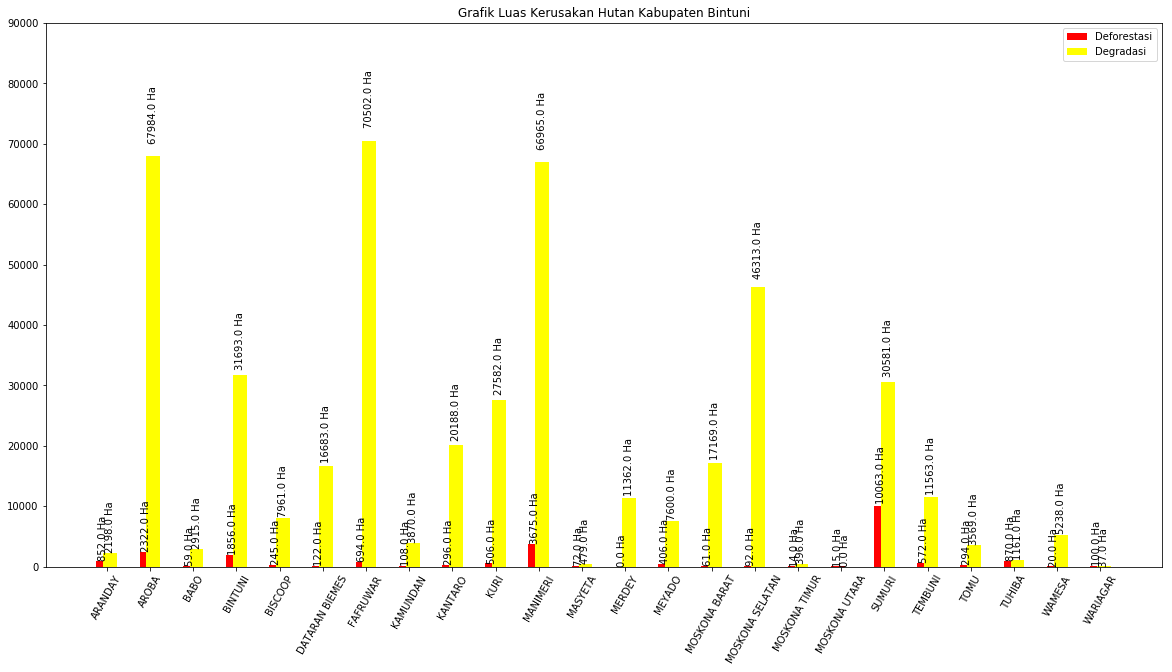

In [548]:
def_deg_chart = def_deg_report[:-1]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(24)
y = def_deg_chart['Total Deforestasi']
y2 = def_deg_chart['Total Degradasi']

fig, ax = plt.subplots(figsize=(20,10))
bar1 = ax.bar(x-0.08,y, width = 0.32, label = "Deforestasi", color = 'red')
bar2 = ax.bar(x+0.08, y2,width = 0.32, label = "Degradasi",color='yellow')

ax.set_xticklabels(list(def_deg_chart.index))
ax.set_title("Grafik Luas Kerusakan Hutan Kabupaten Bintuni")

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2., 1.03*height,
                str(round(height, 0)) + " Ha",
                ha='center', va='bottom',rotation='vertical')
ax.set_ylim([0,90000])
autolabel(bar1)
autolabel(bar2)
plt.xticks(x, rotation=60)
plt.legend()
plt.show()

In [552]:
df_raw_id = df[['OBJECTID','DISTRIK','Tipe','PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID','Luas (Ha)']]
df_raw_id = df_raw_id[df_raw_id['DISTRIK'].notna()]
df_raw_id

hutan = [2001,2002,2004,2005,20041,20051,2006]
nonhutan = [2007,2010,2012,2014,2500,3000,5001,20071,20091,20092,20093,20094,20121,20122,20141,50011]

hutan_ = [2001,2004,2005]
deghutan = [2002,20041,20051,2006]

def deforested(df,x0,x1):
    df[x1+"_Deforested"] = (df[x0].isin(hutan)) & (df[x1].isin(nonhutan))

def degraded(df,x0,x1):
    df[x1+"_Degraded"] = (df[x0].isin(hutan_)) & (df[x1].isin(deghutan))

X0 = ['PL90_ID','PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id']
X1 = ['PL96_ID','PL00_ID','PL03_ID','PL06_ID','PL09_ID','PL11_ID','PL12_ID','PL13_ID','PL14_ID','PL15_ID',
        'pl16_id','pl17_id','PL_18_ID']
    
for i in range(len(X0)):
#    print(X1[i])
#    df_calc[X1[i]+"_Deforested"] = deforested(df_calc,X0[i],X1[i])
    deforested(df_raw_id,X0[i],X1[i])
df_raw_id['Tipe'] = df_raw_id['Tipe'].fillna(value="nonGambut")    

for i in range(len(X0)):
#    print(X1[i])
#    df_calc[X1[i]+"_Deforested"] = deforested(df_calc,X0[i],X1[i])
    degraded(df_raw_id,X0[i],X1[i])
#dg_raw_id['Tipe'] = dg_raw_id['Tipe'].fillna(value="nonGambut")    

df_raw_id.to_csv('raw_merge.csv')